In [ ]:
from langgraph.graph import StateGraph, MessagesState, START, END

def mock_llm(state: MessagesState):
    return {"messages": [{"role": "ai", "content": "Hn kya hua kya karna hai"}]}

graph = StateGraph(MessagesState)
graph.add_node(mock_llm)
graph.add_edge(START, "mock_llm")
graph.add_edge("mock_llm", END)
graph = graph.compile()

graph.invoke({"messages": [{"role": "user", "content": "hi!"}]})

{'messages': [HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='2b547c9d-1cc2-455a-9ea4-0b064a14424a'),
  AIMessage(content='Hn kya hua kya karna hai', additional_kwargs={}, response_metadata={}, id='b4337116-749e-469b-84f5-5d520a82e4ab', tool_calls=[], invalid_tool_calls=[])]}

In [ ]:
pip install -U langgraph

In [ ]:
from langgraph.graph import StateGraph,END
from typing import TypedDict
from IPython.display import Image,display

In [ ]:
class Mystate(TypedDict):
  message:str

def start_node(state:Mystate)->Mystate:
  print('Start node recieved:',state['message'])
  # process or pass the message to the end node
  return {'message':state['message']+"->processed by start"}

# define the end node
def end_node(state:Mystate)->Mystate:
  print('End node recieved:',state['message'])
  return state

# build the graph
builder=StateGraph(Mystate)

In [ ]:
builder

In [ ]:
# Add nodes
builder.add_node('start',start_node)
builder.add_node('end',end_node)


In [ ]:
# define the flow
builder.set_entry_point('start')
builder.add_edge('start','end')
builder.add_edge('end',END) # END is a special marker for graph comletion

In [ ]:
# compile the graph
graph=builder.compile()



In [ ]:
# run the graph
result=graph.invoke({'message':'what is langchain vs langgraph'})
print('Final result:',result['message'])

Start node recieved: what is langchain vs langgraph
End node recieved: what is langchain vs langgraph->processed by start
Final result: what is langchain vs langgraph->processed by start


In [ ]:
# !pip install langgraph langsmith

In [ ]:
# !pip install langchain_groq langchain_community

In [ ]:
grop_api_key=''
langsmith=''

In [ ]:
import os
os.environ['LANGSMITH_TRACING_V2']='true'

In [ ]:
import os

# Enable LangSmith tracing
os.environ["LANGSMITH_TRACING_V2"] = "true"

# Add your LangSmith API key
# os.environ["LANGSMITH_API_KEY"] = "your_langsmith_api_key"

# Optional: Set endpoint and project name
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "My-Colab-Project"

print("LangSmith environment variables set successfully!")

LangSmith environment variables set successfully!


In [ ]:
from langchain_groq import ChatGroq

In [ ]:
llm=ChatGroq(groq_api_key=grop_api_key,model='llama-3.3-70b-versatile')
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x7c3d2adbc140>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x7c3d2af9e4e0>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
graph_builder=StateGraph(State)

In [ ]:
graph_builder

In [ ]:
def chatbot(state:State):
  return {'messages':llm.invoke(state['messages'])}

In [ ]:
graph_builder.add_node('chatbot',chatbot)

In [ ]:
graph_builder

In [ ]:
graph_builder.add_edge(START,'chatbot')
graph_builder.add_edge('chatbot',END)

In [ ]:
graph=graph_builder.compile()

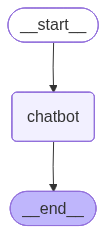

In [ ]:
graph

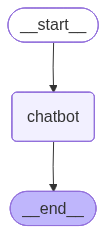

In [ ]:
from IPython.display import Image ,display
try:
  display(Image(graph.get_graph().draw_mermaid_png()))

except Exception:
  pass

In [ ]:

while True:
  user_input=input('User:')
  if user_input.lower() in ['quit','q']:
    print('Good Bye')
    break

  for event in graph.stream({'messages':('user',user_input)}):
    print(event.values())
    for value in event.values():
      print(value['messages'])
      print("Assistant:",value['messages'].content)

dict_values([{'messages': AIMessage(content="It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_tokens': 59, 'completion_time': 0.051605612, 'completion_tokens_details': None, 'prompt_time': 0.000941153, 'prompt_tokens_details': None, 'queue_time': 0.024913966, 'total_time': 0.052546765}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_0761e44d7b', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e4f8a-831e-7202-893a-0b2e4f763f6c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 23, 'total_tokens': 59})}])
content="It's nice to meet you. Is there something I can help you with or would you like to chat?" additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 23, 'prompt_tokens': 36, 'total_t